# Agent-Based Monte Carlo Simulation of a Deliberate Smallpox Release

An individual-level (agent-based) stochastic simulation of the same
smallpox release scenario modeled with differential equations in
`seir_model.ipynb`. Where the compartmental model treats the population as
continuous, well-mixed pools, this model simulates each of N individuals
as a node in a contact network, tracks their disease state day by day, and
runs many stochastic trials, which is closer to how real outbreak
investigators reason about superspreading, chance extinction of small
outbreaks, and the effect of contact network structure (something the
compartmental model can't capture, since it assumes uniform mixing).

## Model structure

- Population represented as a **Watts–Strogatz small-world network** where
  most contacts are local/clustered (household, workplace), with a few
  long-range links (travel, social contact), which is a more realistic
  contact structure than assuming everyone can infect everyone equally.
- Each agent has a state: `S`, `E`, `I`, `Q`, `V`, or `R`, updated once per
  simulated day based on the same smallpox parameters used in the
  compartmental model (R0 ≈ 6, 12-day incubation, 17-day infectious
  period, 30% case fatality).
- Same 21-day detection delay before any response begins.
- Interventions act on the network directly: **ring vaccination**
  vaccinates the direct neighbors of any newly isolated case; **isolation**
  removes an infectious agent's edges (they can no longer transmit).

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

# Same epidemiological parameters as the compartmental model
N = 2000
R0_val = 6.0
incubation_days = 12
infectious_days = 17
case_fatality_rate = 0.30
detection_delay = 21

daily_symptom_prob = 1 / incubation_days   # E -> I
daily_recovery_prob = 1 / infectious_days  # I/Q -> R

# Per-contact daily transmission probability, calibrated so that an
# infectious agent with `avg_degree` contacts over `infectious_days`
# reproduces R0 on average: R0 = avg_degree * p_transmit * infectious_days
avg_degree = 8
p_transmit = R0_val / (avg_degree * infectious_days)
print(f"per-contact daily transmission probability: {p_transmit:.4f}")

per-contact daily transmission probability: 0.0441


In [2]:
def run_agent_simulation(quarantine_prob, vaccination_prob, seed, days=200):
    """Runs one stochastic trial. quarantine_prob / vaccination_prob are
    the DAILY per-agent probabilities of being isolated (if infectious) or
    vaccinated (if a neighbor of an isolated case), applied only after
    `detection_delay`."""
    rng = random.Random(seed)
    G = nx.watts_strogatz_graph(N, k=avg_degree, p=0.1, seed=seed)

    state = {node: 'S' for node in G.nodes}
    index_case = rng.choice(list(G.nodes))
    state[index_case] = 'I'

    history = []

    for day in range(days):
        intervention_active = day >= detection_delay
        new_state = dict(state)

        for node in G.nodes:
            s = state[node]

            if s == 'S':
                for neighbor in G.neighbors(node):
                    if state[neighbor] == 'I' and rng.random() < p_transmit:
                        new_state[node] = 'E'
                        break

            elif s == 'E':
                if rng.random() < daily_symptom_prob:
                    new_state[node] = 'I'

            elif s == 'I':
                if intervention_active and rng.random() < quarantine_prob:
                    new_state[node] = 'Q'
                    if vaccination_prob > 0:
                        for neighbor in G.neighbors(node):
                            if state[neighbor] == 'S' and rng.random() < vaccination_prob:
                                new_state[neighbor] = 'V'
                elif rng.random() < daily_recovery_prob:
                    new_state[node] = 'R'

            elif s == 'Q':
                if rng.random() < daily_recovery_prob:
                    new_state[node] = 'R'

        state = new_state
        counts = {k: sum(1 for v in state.values() if v == k) for k in 'SEIQVR'}
        history.append(counts)

    return history


def summarize(history):
    active = [h['I'] + h['Q'] for h in history]
    total_removed = history[-1]['R']
    return {
        'peak_active': max(active),
        'peak_day': int(np.argmax(active)),
        'total_infected': total_removed,
        'estimated_deaths': total_removed * case_fatality_rate,
        'active_over_time': active,
    }

In [3]:
N_TRIALS = 15

scenario_params = {
    'No intervention':             dict(quarantine_prob=0.0,  vaccination_prob=0.0),
    'Ring vaccination + isolation': dict(quarantine_prob=0.35, vaccination_prob=0.4),
    'Mass vaccination':            dict(quarantine_prob=0.1,  vaccination_prob=0.6),
}

results = {label: [] for label in scenario_params}

for label, params in scenario_params.items():
    for trial in range(N_TRIALS):
        history = run_agent_simulation(seed=trial, **params)
        results[label].append(summarize(history))
    print(f"{label}: {N_TRIALS} trials complete")

No intervention: 15 trials complete
Ring vaccination + isolation: 15 trials complete
Mass vaccination: 15 trials complete


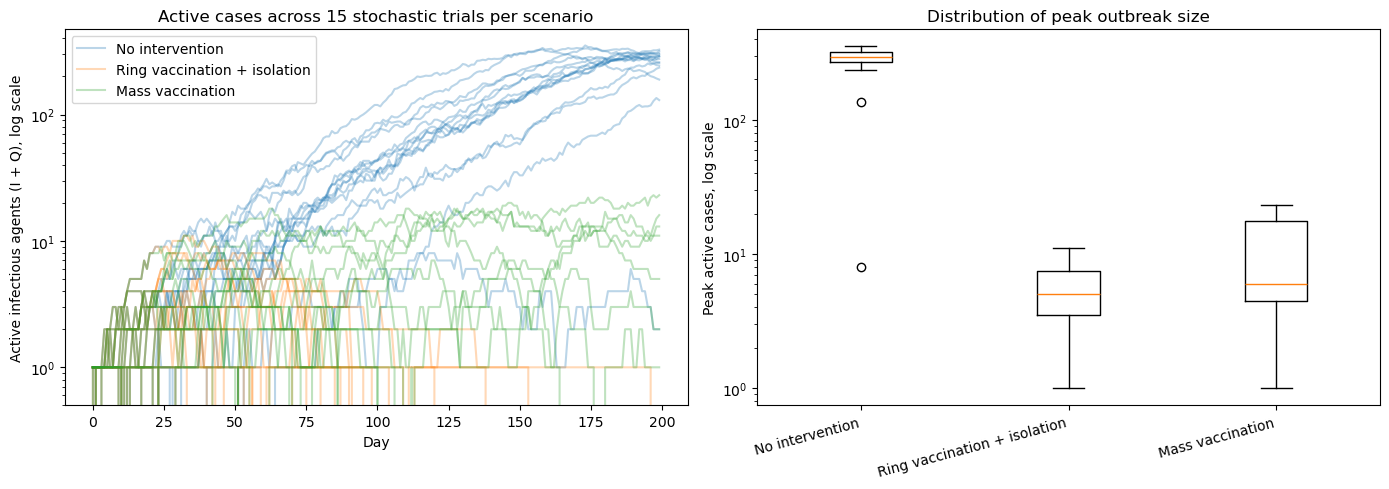

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'No intervention': 'tab:blue', 'Ring vaccination + isolation': 'tab:orange', 'Mass vaccination': 'tab:green'}

for label, trials in results.items():
    for i, trial in enumerate(trials):
        axes[0].plot(trial['active_over_time'], color=colors[label], alpha=0.3,
                     label=label if i == 0 else None)

axes[0].set_yscale('log')
axes[0].set_ylim(bottom=0.5)
axes[0].set_title(f'Active cases across {N_TRIALS} stochastic trials per scenario')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Active infectious agents (I + Q), log scale')
axes[0].legend()

peak_data = [[t['peak_active'] for t in trials] for trials in results.values()]
axes[1].boxplot(peak_data, labels=list(results.keys()))
axes[1].set_yscale('log')
axes[1].set_title('Distribution of peak outbreak size')
axes[1].set_ylabel('Peak active cases, log scale')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('agent_based_scenarios.png', dpi=120)
plt.show()

In [ ]:
print(f"{'Scenario':<32}{'Mean peak':>14}{'Median peak':>14}{'Mean deaths':>14}{'Trials extinct <10':>22}")
for label, trials in results.items():
    peaks = [t['peak_active'] for t in trials]
    deaths = [t['estimated_deaths'] for t in trials]
    fizzled = sum(1 for p in peaks if p < 10)
    print(f"{label:<32}{np.mean(peaks):>14.1f}{np.median(peaks):>14.1f}{np.mean(deaths):>14.1f}{fizzled:>22}/{N_TRIALS}")

Scenario                             Mean peak   Median peak   Mean deaths    Trials extinct <10
No intervention                          271.3         294.0         281.2                     1/15
Ring vaccination + isolation               5.1           5.0           3.7                    14/15
Mass vaccination                           9.8           6.0          12.8                     9/15


## Results and comparison to the SEIR model

The Monte Carlo trials show something the deterministic SEIR model
structurally cannot: **variance**. Some trials under "no intervention"
fizzle out early purely by chance (the index case's early contacts happen
not to be susceptible, or happen to recover before transmitting). A
possibility the compartmental model erases by construction, since it
represents expected values, not individual chance events.

With interventions active, this stochastic effect becomes the main story:
a meaningful fraction of trials go extinct with fewer than 10 total cases,
something no compartmental model can show, since it always predicts the
same peak for the same parameters. This matters for real biodefense
planning because it is the difference between "this response strategy reduces
average outbreak size" (compartmental) and "this response strategy has a
real chance of stopping the outbreak outright before it takes hold"
(agent-based), which is a materially different and arguably more useful
claim for emergency planning.